In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [6]:
# fetching the data and creating dataFrame
job_postings_dataset = pd.read_csv("job_postings.csv")
job_postings_dataframe = pd.DataFrame(job_postings_dataset)

# checking the information of dataframe
job_postings_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15887 entries, 0 to 15886
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_id                      15887 non-null  int64  
 1   company_id                  15520 non-null  float64
 2   title                       15887 non-null  object 
 3   description                 15886 non-null  object 
 4   max_salary                  5522 non-null   float64
 5   med_salary                  981 non-null    float64
 6   min_salary                  5522 non-null   float64
 7   pay_period                  6503 non-null   object 
 8   formatted_work_type         15887 non-null  object 
 9   location                    15887 non-null  object 
 10  applies                     8700 non-null   float64
 11  original_listed_time        15887 non-null  float64
 12  remote_allowed              2340 non-null   float64
 13  views                       131

In [7]:
#  finding the number of fetaures and rows of the data
job_postings_dataframe.shape

(15887, 27)

In [8]:
#  finding the statistic of the given dataset for better analysis
job_postings_dataframe.describe()

,job_id,company_id,max_salary,med_salary,min_salary,applies,original_listed_time,remote_allowed,views,expiry,closed_time,listed_time,sponsored
count,1.588700e+04,1.552000e+04,5.522000e+03,981.000000,5522.000000,8700.000000,1.588700e+04,2340.0,13124.000000,1.588700e+04,9.280000e+02,1.588700e+04,15887.000000
mean,3.691066e+09,1.084100e+07,8.832964e+04,41167.664404,62349.213325,22.833103,1.690000e+12,1.0,76.771106,1.700765e+12,1.690000e+12,1.690000e+12,0.289293
std,1.067637e+08,2.313688e+07,9.067592e+04,93682.094905,59482.723713,54.892826,0.000000e+00,0.0,167.453897,2.710282e+09,0.000000e+00,0.000000e+00,0.453449
min,8.500877e+07,1.009000e+03,1.000000e+01,10.000000,10.000000,1.000000,1.690000e+12,1.0,1.000000,1.690000e+12,1.690000e+12,1.690000e+12,0.000000
25%,3.693071e+09,1.301100e+04,4.802000e+01,18.000000,38.000000,2.000000,1.690000e+12,1.0,6.000000,1.700000e+12,1.690000e+12,1.690000e+12,0.000000
50%,3.697358e+09,2.777685e+05,8.200000e+04,26.000000,60000.000000,6.000000,1.690000e+12,1.0,25.000000,1.700000e+12,1.690000e+12,1.690000e+12,0.000000
75%,3.699413e+09,7.798499e+06,1.400000e+05,52000.000000,98981.000000,21.000000,1.690000e+12,1.0,78.000000,1.700000e+12,1.690000e+12,1.690000e+12,1.000000
max,3.701374e+09,9.856222e+07,1.300000e+06,998426.000000,800000.000000,1615.000000,1.690000e+12,1.0,5656.000000,1.710000e+12,1.690000e+12,1.690000e+12,1.000000


In [9]:
#  finding null value in each of the features in dataset
missing_values = job_postings_dataframe.isnull()
for columns in missing_values.columns.values.tolist():
    print(missing_values[columns].value_counts(),end="\n")


job_id
False    15887
Name: count, dtype: int64
company_id
False    15520
True       367
Name: count, dtype: int64
title
False    15887
Name: count, dtype: int64
description
False    15886
True         1
Name: count, dtype: int64
max_salary
True     10365
False     5522
Name: count, dtype: int64
med_salary
True     14906
False      981
Name: count, dtype: int64
min_salary
True     10365
False     5522
Name: count, dtype: int64
pay_period
True     9384
False    6503
Name: count, dtype: int64
formatted_work_type
False    15887
Name: count, dtype: int64
location
False    15887
Name: count, dtype: int64
applies
False    8700
True     7187
Name: count, dtype: int64
original_listed_time
False    15887
Name: count, dtype: int64
remote_allowed
True     13547
False     2340
Name: count, dtype: int64
views
False    13124
True      2763
Name: count, dtype: int64
job_posting_url
False    15887
Name: count, dtype: int64
application_url
False    9795
True     6092
Name: count, dtype: int64
applicati

In [10]:
#  Drop duplicates values if present and keep the lastest value
job_postings_dataframe.drop_duplicates(keep='last', inplace=True)


In [11]:
# fill the columns like applies or views with 0 if blank for handling missing data 
job_postings_dataframe['applies'].fillna(0, inplace=True)
job_postings_dataframe['views'].fillna(0, inplace=True)
job_postings_dataframe['remote_allowed'].fillna(0, inplace=True)


C:\Users\amrut\AppData\Local\Temp\ipykernel_29064\597194553.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  job_postings_dataframe['applies'].fillna(0, inplace=True)
C:\Users\amrut\AppData\Local\Temp\ipykernel_29064\597194553.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



In [12]:
# Text formatting for string type columns to make data consistent
job_postings_dataframe.loc[:, 'formatted_work_type'] = job_postings_dataframe.loc[:, 'formatted_work_type'].str.upper()
job_postings_dataframe.loc[:, 'work_type'] = job_postings_dataframe.loc[:, 'work_type'].str.upper()
job_postings_dataframe.loc[:, 'formatted_experience_level'] = job_postings_dataframe.loc[:, 'formatted_experience_level'].str.upper()
job_postings_dataframe.loc[:, 'application_type'] = job_postings_dataframe.loc[:, 'application_type'].str.upper()

In [13]:
# Encode categorical values using Label encoding
job_postings_dataframe.loc[:, 'formatted_work_type'] = job_postings_dataframe.loc[:, 'formatted_work_type'].astype('category').cat.codes
job_postings_dataframe.loc[:, 'work_type'] = job_postings_dataframe.loc[:, 'work_type'].astype('category').cat.codes
job_postings_dataframe.loc[:, 'job_posting_url'] = job_postings_dataframe.loc[:, 'job_posting_url'].astype('category').cat.codes
job_postings_dataframe.loc[:, 'application_url'] = job_postings_dataframe.loc[:, 'application_url'].astype('category').cat.codes
job_postings_dataframe.loc[:, 'posting_domain'] = job_postings_dataframe.loc[:, 'posting_domain'].astype('category').cat.codes

In [14]:
# data type conversion from number to date time  for Data time fields
def convert_to_datetime(dataFrame, columnName):
    dataFrame[columnName] = dataFrame[columnName].astype(float)
    dataFrame[columnName] = pd.to_datetime(dataFrame[columnName], unit='ms')

convert_to_datetime(job_postings_dataframe, 'expiry')
convert_to_datetime(job_postings_dataframe, 'original_listed_time')
convert_to_datetime(job_postings_dataframe, 'listed_time')
convert_to_datetime(job_postings_dataframe, 'closed_time')

job_postings_dataframe

,job_id,company_id,title,description,max_salary,med_salary,min_salary,pay_period,formatted_work_type,location,...,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type
1,85008768,NaN,Licensed Insurance Agent,While many industries were hurt by the last fe...,52000.0,NaN,45760.0,YEARLY,1,"Chico, CA",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,1,1,USD,BASE_SALARY
2,133114754,77766802.0,Sales Manager,Are you a dynamic and creative marketing profe...,NaN,NaN,NaN,NaN,1,"Santa Clarita, CA",...,2023-11-14 22:13:20,NaT,NaN,NaN,2023-07-22 04:26:40,-1,0,1,NaN,NaN
3,133196985,1089558.0,Model Risk Auditor,Join Us as a Model Risk Auditor – Showcase You...,NaN,NaN,NaN,NaN,0,"New York, NY",...,2023-11-14 22:13:20,NaT,NaN,NaN,2023-07-22 04:26:40,-1,0,0,NaN,NaN
4,381055942,96654609.0,Business Manager,Business ManagerFirst Baptist Church ForneyFor...,NaN,NaN,NaN,NaN,1,"Forney, TX",...,2023-11-14 22:13:20,NaT,NaN,NaN,2023-07-22 04:26:40,-1,0,1,NaN,NaN
5,529257371,1244539.0,NY Studio Assistant,YOU COULD BE ONE OF THE MAGIC MAKERS\nKen Fulk...,NaN,NaN,NaN,NaN,1,"New York, NY",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,1,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15882,3701373516,74718032.0,Sanitation Technician,"Location:\n\nWest Columbia, SC, US, 29172\n\n2...",NaN,NaN,NaN,NaN,4,"West Columbia, SC",...,2023-11-14 22:13:20,NaT,ENTRY LEVEL,NaN,2023-07-22 04:26:40,56,0,4,NaN,NaN
15883,3701373522,38897.0,Unit Secretary,Job Title: Unit Secretary\nDepartment: Nursing...,NaN,NaN,NaN,NaN,1,"Teaneck, NJ",...,2023-11-14 22:13:20,NaT,ENTRY LEVEL,NaN,2023-07-22 04:26:40,985,0,1,NaN,NaN
15884,3701373523,38897.0,"Radiology Aide, Perdiem","Job Title: Radiology Aide, Perdiem\nDepartment...",NaN,NaN,NaN,NaN,4,"Teaneck, NJ",...,2023-11-14 22:13:20,NaT,ENTRY LEVEL,NaN,2023-07-22 04:26:40,985,0,4,NaN,NaN
15885,3701373524,2623.0,MRI Manager,Grade 105\nJob Type: Officer of Administration...,135000.0,NaN,110000.0,YEARLY,1,"New York, NY",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,931,0,1,USD,BASE_SALARY


In [15]:
# Dropping null values (max_salary and min_salary are important to predict , so dropping the null values as they are irrelevant)
job_postings_dataframe.dropna(subset=['max_salary', 'min_salary'], axis=0, inplace=True)


In [16]:
# Inconsistent data handling (Finding  median salary fron max_salary and min_salary where it is absent)
job_postings_dataframe["med_salary"] = job_postings_dataframe.apply(lambda x: 
    (x["max_salary"] + x["min_salary"]) / 2 if x["max_salary"] and x["min_salary"] is not None 
    else x["med_salary"], axis=1)
job_postings_dataframe

,job_id,company_id,title,description,max_salary,med_salary,min_salary,pay_period,formatted_work_type,location,...,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type
1,85008768,NaN,Licensed Insurance Agent,While many industries were hurt by the last fe...,52000.00,48880.000,45760.00,YEARLY,1,"Chico, CA",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,1,1,USD,BASE_SALARY
6,903408693,3894635.0,Office Associate,Provide clerical and administrative support to...,42000.00,39500.000,37000.00,YEARLY,1,"Albany, GA",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,1,1,USD,BASE_SALARY
9,1029078768,61469.0,Registered Nurse (RN) Vaccinator,United Staffing Solutions is partnering with o...,50.00,50.000,50.00,HOURLY,4,"Muskegon, MI",...,2023-11-14 22:13:20,NaT,NaN,NaN,2023-07-22 04:26:40,-1,0,4,USD,BASE_SALARY
13,1535492735,NaN,Administrative Assistant,We are looking for a responsible Administrativ...,20.00,19.000,18.00,HOURLY,4,"Ocoee, FL",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,0,4,USD,BASE_SALARY
14,1657978824,89350959.0,"REMOTE STEEL BUILDING SALES MAKE $1,000 TO $30...","REMOTE WORK FROM HOME $1,000 TO $10,000 COMMIS...",12000.00,12000.000,12000.00,MONTHLY,0,"Texas, United States",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,0,0,USD,BASE_SALARY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15871,3701373383,13651.0,Senior Analyst,About Us\nMarketAxess is on a journey to digit...,85000.00,80000.000,75000.00,YEARLY,1,"New York, NY",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,79,0,1,USD,BASE_SALARY
15872,3701373385,18312164.0,Sales Manager,"Sales ManagerTexas, US $60,000–$70,000OTE $250...",70000.00,65000.000,60000.00,YEARLY,1,"Texas, United States",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,-1,0,1,USD,BASE_SALARY
15876,3701373427,1321042.0,Design Intern,Looking to redefine the skyline or to be a par...,23.89,21.485,19.08,HOURLY,2,"Miramar, FL",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,1138,0,2,USD,BASE_SALARY
15879,3701373493,5619.0,Sr. Bilingual Copywriter (Canadian French),Overview\nTHE ROLE:\nThe Senior Bilingual Copy...,105200.00,98550.000,91900.00,YEARLY,1,"Torrance, CA",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,663,0,1,USD,BASE_SALARY


In [17]:
# Data Transformation/ Normalization (the max_salary ,min_salary and med_salary based on the Pay period)
def normalize_pay_period(dataframe, columnName):
    yearly = 1
    monthly = 12
    hourly = 40*52

    dataframe[columnName] = dataframe.apply(lambda x: x[columnName] * hourly if x['pay_period'] == ('HOURLY')
                                            else (x[columnName] * monthly if x['pay_period'] == ('MONTHLY')
                                            else x[columnName] * yearly ), axis=1)
    

normalize_pay_period(job_postings_dataframe, 'max_salary')
normalize_pay_period(job_postings_dataframe, 'min_salary')
normalize_pay_period(job_postings_dataframe, 'med_salary')
job_postings_dataframe['pay_period'] =  'YEARLY'
job_postings_dataframe
    

,job_id,company_id,title,description,max_salary,med_salary,min_salary,pay_period,formatted_work_type,location,...,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type
1,85008768,NaN,Licensed Insurance Agent,While many industries were hurt by the last fe...,52000.0,48880.0,45760.0,YEARLY,1,"Chico, CA",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,1,1,USD,BASE_SALARY
6,903408693,3894635.0,Office Associate,Provide clerical and administrative support to...,42000.0,39500.0,37000.0,YEARLY,1,"Albany, GA",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,1,1,USD,BASE_SALARY
9,1029078768,61469.0,Registered Nurse (RN) Vaccinator,United Staffing Solutions is partnering with o...,104000.0,104000.0,104000.0,YEARLY,4,"Muskegon, MI",...,2023-11-14 22:13:20,NaT,NaN,NaN,2023-07-22 04:26:40,-1,0,4,USD,BASE_SALARY
13,1535492735,NaN,Administrative Assistant,We are looking for a responsible Administrativ...,41600.0,39520.0,37440.0,YEARLY,4,"Ocoee, FL",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,0,4,USD,BASE_SALARY
14,1657978824,89350959.0,"REMOTE STEEL BUILDING SALES MAKE $1,000 TO $30...","REMOTE WORK FROM HOME $1,000 TO $10,000 COMMIS...",144000.0,144000.0,144000.0,YEARLY,0,"Texas, United States",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,0,0,USD,BASE_SALARY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15871,3701373383,13651.0,Senior Analyst,About Us\nMarketAxess is on a journey to digit...,85000.0,80000.0,75000.0,YEARLY,1,"New York, NY",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,79,0,1,USD,BASE_SALARY
15872,3701373385,18312164.0,Sales Manager,"Sales ManagerTexas, US $60,000–$70,000OTE $250...",70000.0,65000.0,60000.0,YEARLY,1,"Texas, United States",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,-1,0,1,USD,BASE_SALARY
15876,3701373427,1321042.0,Design Intern,Looking to redefine the skyline or to be a par...,49691.2,44688.8,39686.4,YEARLY,2,"Miramar, FL",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,1138,0,2,USD,BASE_SALARY
15879,3701373493,5619.0,Sr. Bilingual Copywriter (Canadian French),Overview\nTHE ROLE:\nThe Senior Bilingual Copy...,105200.0,98550.0,91900.0,YEARLY,1,"Torrance, CA",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,663,0,1,USD,BASE_SALARY


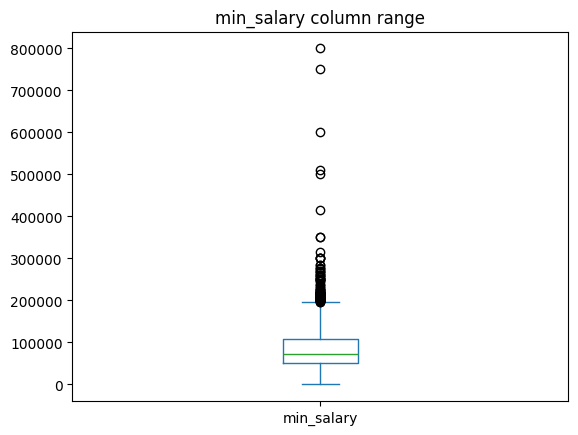

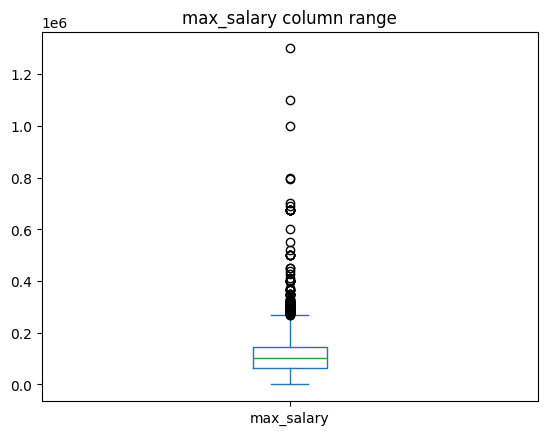

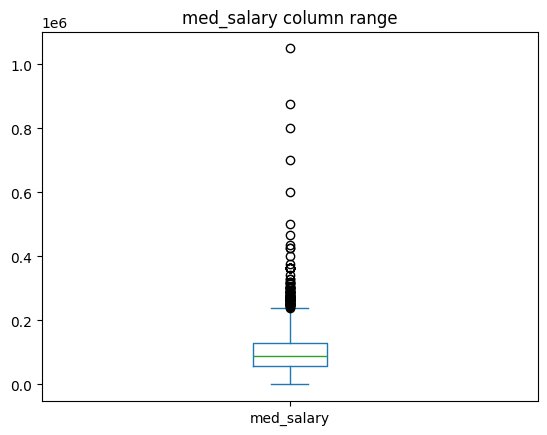

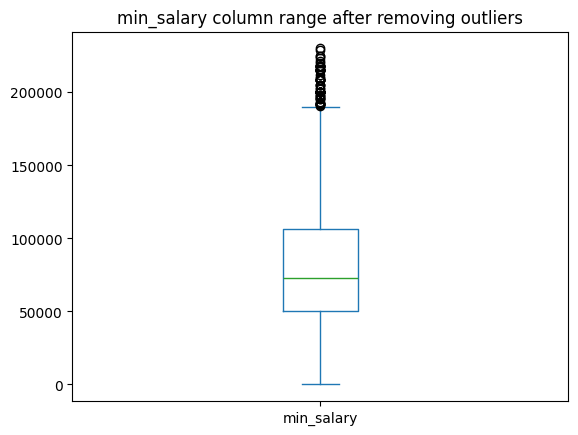

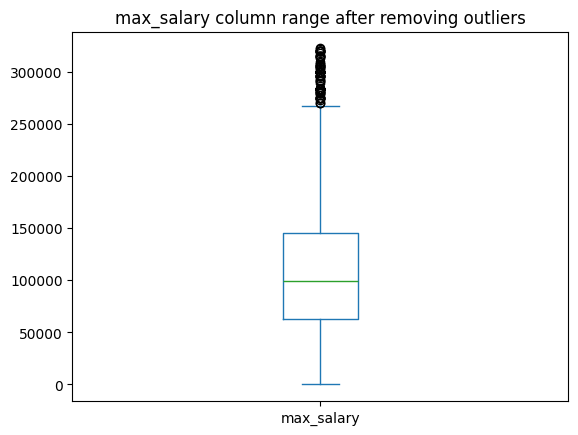

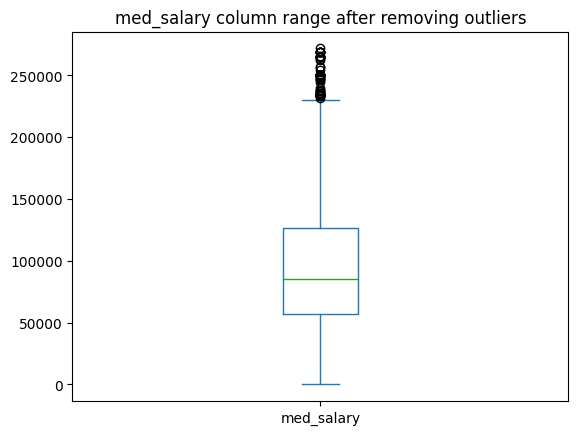

,job_id,company_id,title,description,max_salary,med_salary,min_salary,pay_period,formatted_work_type,location,...,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type
1,85008768,NaN,Licensed Insurance Agent,While many industries were hurt by the last fe...,52000.0,48880.0,45760.0,YEARLY,1,"Chico, CA",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,1,1,USD,BASE_SALARY
6,903408693,3894635.0,Office Associate,Provide clerical and administrative support to...,42000.0,39500.0,37000.0,YEARLY,1,"Albany, GA",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,1,1,USD,BASE_SALARY
9,1029078768,61469.0,Registered Nurse (RN) Vaccinator,United Staffing Solutions is partnering with o...,104000.0,104000.0,104000.0,YEARLY,4,"Muskegon, MI",...,2023-11-14 22:13:20,NaT,NaN,NaN,2023-07-22 04:26:40,-1,0,4,USD,BASE_SALARY
13,1535492735,NaN,Administrative Assistant,We are looking for a responsible Administrativ...,41600.0,39520.0,37440.0,YEARLY,4,"Ocoee, FL",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,0,4,USD,BASE_SALARY
14,1657978824,89350959.0,"REMOTE STEEL BUILDING SALES MAKE $1,000 TO $30...","REMOTE WORK FROM HOME $1,000 TO $10,000 COMMIS...",144000.0,144000.0,144000.0,YEARLY,0,"Texas, United States",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,0,0,USD,BASE_SALARY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15871,3701373383,13651.0,Senior Analyst,About Us\nMarketAxess is on a journey to digit...,85000.0,80000.0,75000.0,YEARLY,1,"New York, NY",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,79,0,1,USD,BASE_SALARY
15872,3701373385,18312164.0,Sales Manager,"Sales ManagerTexas, US $60,000–$70,000OTE $250...",70000.0,65000.0,60000.0,YEARLY,1,"Texas, United States",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,-1,0,1,USD,BASE_SALARY
15876,3701373427,1321042.0,Design Intern,Looking to redefine the skyline or to be a par...,49691.2,44688.8,39686.4,YEARLY,2,"Miramar, FL",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,1138,0,2,USD,BASE_SALARY
15879,3701373493,5619.0,Sr. Bilingual Copywriter (Canadian French),Overview\nTHE ROLE:\nThe Senior Bilingual Copy...,105200.0,98550.0,91900.0,YEARLY,1,"Torrance, CA",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,663,0,1,USD,BASE_SALARY


In [18]:
# removing outliers from salary columns so that it will not affect prediction in future using interquartile range.
def remove_outliers(dataframe, columnName):
    q1 = np.percentile(dataframe.loc[:, columnName], 25)
    q3 = np.percentile(dataframe.loc[:, columnName], 75)

    iqr_value = 1.5 * (q3 - q1)
    
    upper_bound = q3 + 1.5 * iqr_value
    lower_bound = q1 - 1.5 * iqr_value
    
    index_choose_lower = dataframe[(dataframe.loc[:, columnName] < lower_bound)].index
    dataframe.drop(index_choose_lower, inplace=True)

    index_choose_upper = dataframe[(dataframe.loc[:, columnName] > upper_bound)].index
    dataframe.drop(index_choose_upper, inplace=True)

# showing overall entries in min_salary, max_salary, med_salary column including outliers using box plot
job_postings_dataframe['min_salary'].plot(kind="box")
plt.title("min_salary column range")
plt.show()

job_postings_dataframe['max_salary'].plot(kind="box")
plt.title("max_salary column range")
plt.show()

job_postings_dataframe['med_salary'].plot(kind="box")
plt.title("med_salary column range")
plt.show()

# removed outlier using function defined above.
remove_outliers(job_postings_dataframe, 'max_salary')
remove_outliers(job_postings_dataframe, 'min_salary')
remove_outliers(job_postings_dataframe, 'med_salary')

# showing overall entries in min_salary after removing outliers using box-plot
job_postings_dataframe['min_salary'].plot(kind="box")
plt.title("min_salary column range after removing outliers")
plt.show()

job_postings_dataframe['max_salary'].plot(kind="box")
plt.title("max_salary column range after removing outliers")
plt.show()

job_postings_dataframe['med_salary'].plot(kind="box")
plt.title("med_salary column range after removing outliers")
plt.show()

job_postings_dataframe

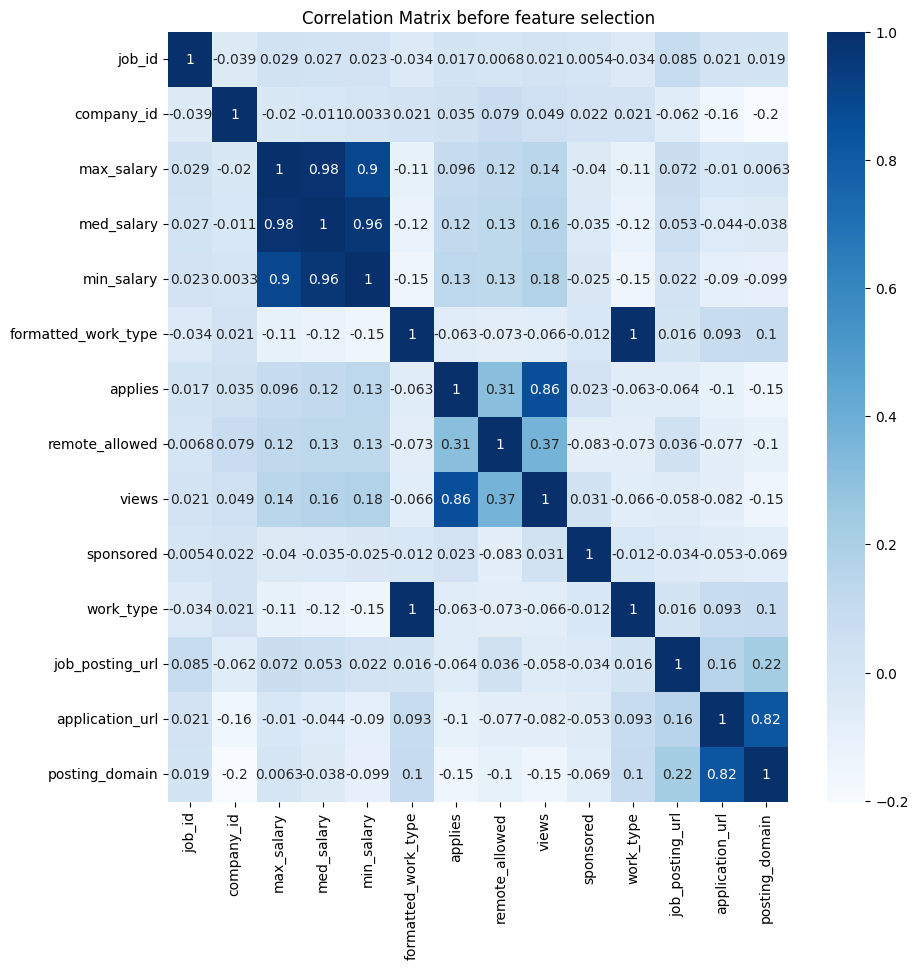

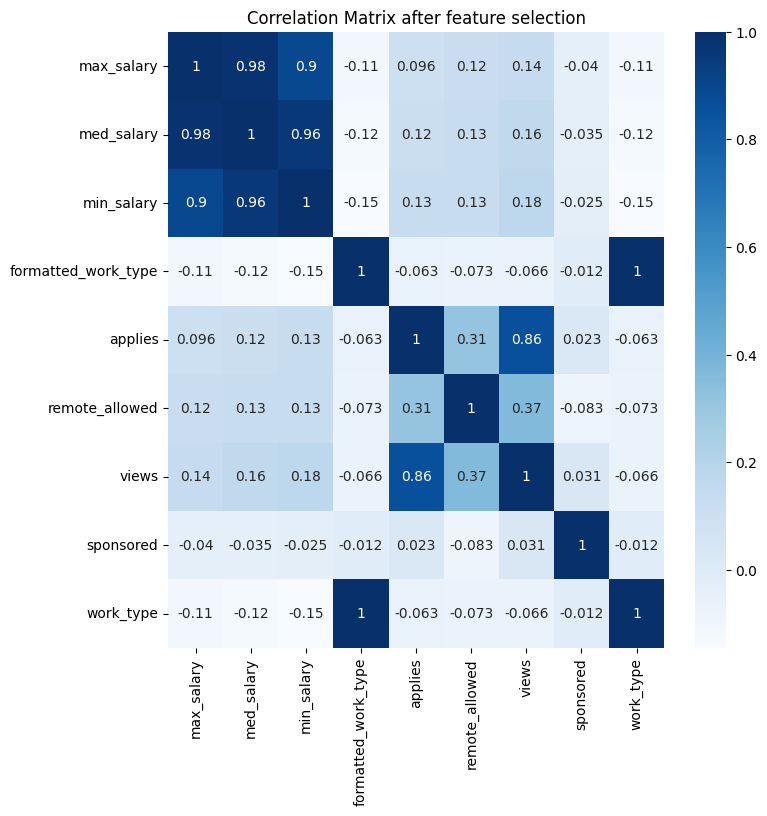

,title,description,max_salary,med_salary,min_salary,pay_period,formatted_work_type,location,applies,original_listed_time,...,application_type,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,sponsored,work_type,currency,compensation_type
1,Licensed Insurance Agent,While many industries were hurt by the last fe...,52000.0,48880.0,45760.0,YEARLY,1,"Chico, CA",0.0,2023-07-22 04:26:40,...,COMPLEXONSITEAPPLY,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,1,1,USD,BASE_SALARY
6,Office Associate,Provide clerical and administrative support to...,42000.0,39500.0,37000.0,YEARLY,1,"Albany, GA",5.0,2023-07-22 04:26:40,...,COMPLEXONSITEAPPLY,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,1,1,USD,BASE_SALARY
9,Registered Nurse (RN) Vaccinator,United Staffing Solutions is partnering with o...,104000.0,104000.0,104000.0,YEARLY,4,"Muskegon, MI",0.0,2023-07-22 04:26:40,...,COMPLEXONSITEAPPLY,2023-11-14 22:13:20,NaT,NaN,NaN,2023-07-22 04:26:40,0,4,USD,BASE_SALARY
13,Administrative Assistant,We are looking for a responsible Administrativ...,41600.0,39520.0,37440.0,YEARLY,4,"Ocoee, FL",3.0,2023-07-22 04:26:40,...,COMPLEXONSITEAPPLY,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,0,4,USD,BASE_SALARY
14,"REMOTE STEEL BUILDING SALES MAKE $1,000 TO $30...","REMOTE WORK FROM HOME $1,000 TO $10,000 COMMIS...",144000.0,144000.0,144000.0,YEARLY,0,"Texas, United States",0.0,2023-07-22 04:26:40,...,OFFSITEAPPLY,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,0,0,USD,BASE_SALARY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15871,Senior Analyst,About Us\nMarketAxess is on a journey to digit...,85000.0,80000.0,75000.0,YEARLY,1,"New York, NY",14.0,2023-07-22 04:26:40,...,OFFSITEAPPLY,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,0,1,USD,BASE_SALARY
15872,Sales Manager,"Sales ManagerTexas, US $60,000–$70,000OTE $250...",70000.0,65000.0,60000.0,YEARLY,1,"Texas, United States",7.0,2023-07-22 04:26:40,...,OFFSITEAPPLY,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,0,1,USD,BASE_SALARY
15876,Design Intern,Looking to redefine the skyline or to be a par...,49691.2,44688.8,39686.4,YEARLY,2,"Miramar, FL",2.0,2023-07-22 04:26:40,...,OFFSITEAPPLY,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,0,2,USD,BASE_SALARY
15879,Sr. Bilingual Copywriter (Canadian French),Overview\nTHE ROLE:\nThe Senior Bilingual Copy...,105200.0,98550.0,91900.0,YEARLY,1,"Torrance, CA",4.0,2023-07-22 04:26:40,...,OFFSITEAPPLY,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,0,1,USD,BASE_SALARY


In [19]:
# This heatmap shows the correlation between all the numerical columns of the dataset.
numerical_columns = job_postings_dataframe[['job_id', 'company_id', 'max_salary', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 
                                            'remote_allowed', 'views', 'sponsored', 'work_type', 'job_posting_url', 'application_url', 'posting_domain']]
job_posting_correlation = numerical_columns.corr()
plt.figure(figsize = (10,10))
sns.heatmap(job_posting_correlation, annot=True, cmap="Blues")
plt.title("Correlation Matrix before feature selection")
plt.show()

# dropping not required columns to perform dimensionality reduction
job_postings_dataframe.drop(columns=['job_posting_url', 'application_url', 'posting_domain', 'job_id', 'company_id'], axis=1, inplace=True)

# This heatmap shows the correlation between all the numerical columns of the dataset.
numerical_columns = job_postings_dataframe[['max_salary', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 
                                            'remote_allowed', 'views', 'sponsored', 'work_type']]
job_posting_correlation = numerical_columns.corr()
plt.figure(figsize = (8,8))
sns.heatmap(job_posting_correlation, annot=True, cmap="Blues")
plt.title("Correlation Matrix after feature selection")
plt.show()

job_postings_dataframe

In [20]:
# creating a csv file for cleaned data
job_postings_dataframe.to_csv("job_postings_cleaned.csv", index=False)

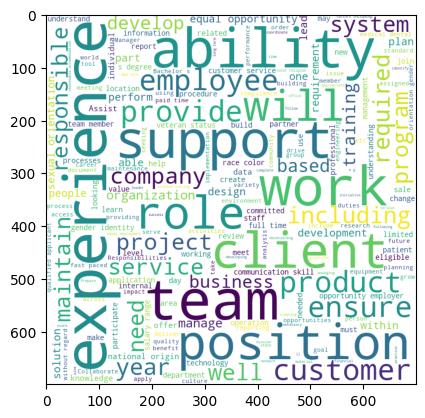

<Figure size 1000x1000 with 0 Axes>

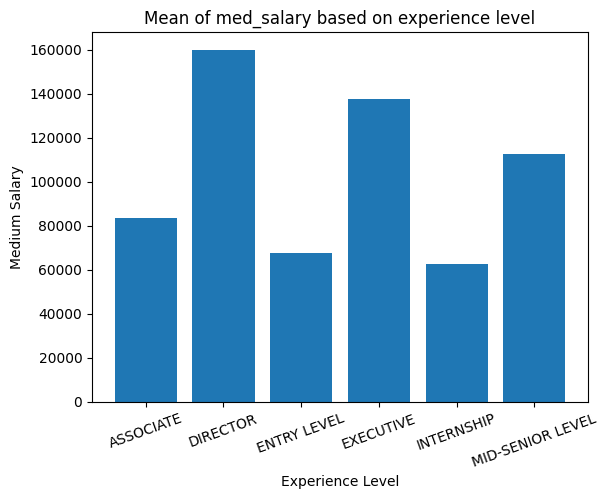

C:\Users\amrut\AppData\Local\Temp\ipykernel_29064\3304659337.py:16: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(job_postings_dataframe['formatted_experience_level']).plot.bar()


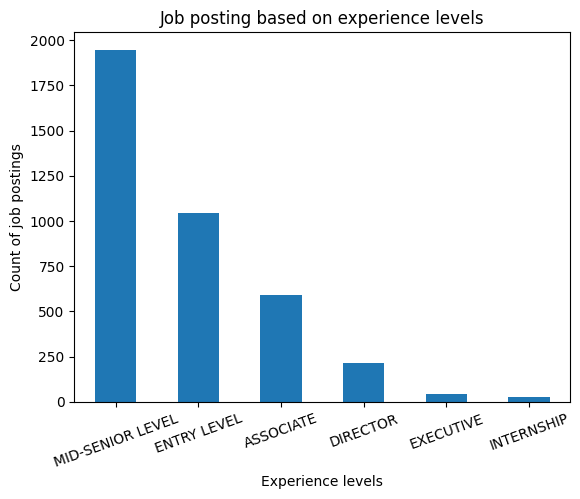

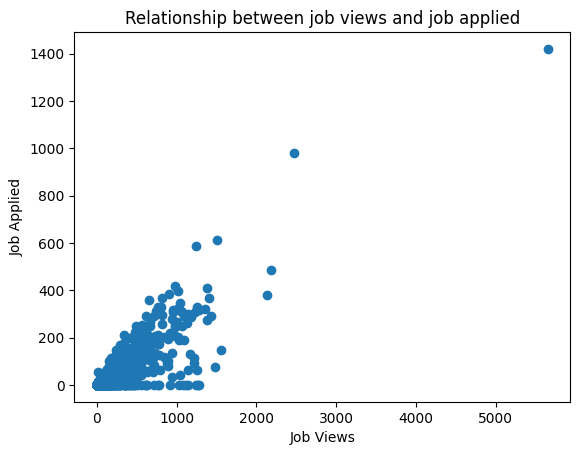

In [21]:
# this word cloud shows the commonly used words in description column 
wordcloud = WordCloud(width=700, height=700, background_color='White').generate(' '.join(job_postings_dataframe['description']))
plt.imshow(wordcloud)
plt.figure(figsize=(10, 10))
plt.show()

job_posting_experience = job_postings_dataframe.groupby("formatted_experience_level")[["med_salary"]].mean()
plt.bar(job_posting_experience.index, job_posting_experience['med_salary'])
plt.title("Mean of med_salary based on experience level")
plt.xlabel("Experience Level")
plt.xticks(rotation=20)
plt.ylabel("Medium Salary")
plt.show()

# This bar graph shows the number of job postings based on experience levels
pd.value_counts(job_postings_dataframe['formatted_experience_level']).plot.bar()
plt.title("Job posting based on experience levels")
plt.xlabel("Experience levels")
plt.xticks(rotation=20)
plt.ylabel("Count of job postings")
plt.show()

x = job_postings_dataframe['views']
y = job_postings_dataframe['applies']
plt.scatter(x, y)
plt.title("Relationship between job views and job applied")
plt.xlabel("Job Views")
plt.ylabel("Job Applied")
plt.show()
